## 📋 THÔNG TIN THÀNH VIÊN

| STT | Họ và tên | MSSV |
|:---:|:---|:---:|
| 1 | **Đặng Vĩnh Khang** | `23280028` |
| 2 | **Phan Nguyễn Minh Nhựt** | `23280032` |
| 3 | **Đinh Bình An** | `23280034` |

# 1. KHỞI TẠO BAN ĐẦU

In [1]:
# Import thư viện cần thiết
import sys
import pandas as pd
import importlib
import matplotlib.pyplot as plt
import seaborn as sns
import argparse
import configparser
import logging
import json
import joblib
from pathlib import Path
import numpy as np



# 2. TIỀN XỬ LÍ DỮ LIỆU VÀ EDA

## 2.1. Tải module và dataset



In [2]:
sys.path.append(r"C:\Users\Dinh Binh An\OneDrive\Dai_hoc\nhap_mon_python\final_project\project_root\source_code\preprocessing")

# Import module
from PreprocessingData import DataPreprocessor



In [3]:
# Đọc file data bds_full_data.csv
path = r"C:\Users\Dinh Binh An\OneDrive\Dai_hoc\nhap_mon_python\final_project\project_root\Data\district_csv_data\bds_full_data.csv"  #<== ĐỔI ĐƯỜNG DẪN FILE TẠI ĐÂY
df = DataPreprocessor.read_file(path)

df.head()

C:\Users\Dinh Binh An\OneDrive\Dai_hoc\nhap_mon_python\final_project\project_root\source_code\preprocessing\PreprocessingData.py:26: DtypeWarning: Columns (15,16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path, header=header)


,id,address,district,Diện tích,Số tầng,Số phòng ngủ,"Số phòng tắm, vệ sinh",Mặt tiền,Đường vào,Hướng nhà,Hướng ban công,Pháp lý,Nội thất,Thời gian dự kiến vào ở,Khoảng giá,Mức giá điện,Mức giá nước,Mức giá internet,Tiện ích
0,43389445,"Dự án Centana City Điền Phúc Thành, Phường Lon...",Quận 9,80 m²,3 tầng,4 phòng,4 phòng,NaN,12 m,Đông,NaN,Sổ đỏ/ Sổ hồng,Không nội thất,NaN,"7,9 tỷ",NaN,NaN,NaN,NaN
1,44206120,"Đường Ấp Chiến Lược, Phường Bình Hưng Hòa A, B...",Bình Tân,143 m²,1 tầng,1 phòng,1 phòng,"4,2 m",12 m,NaN,NaN,Sổ đỏ/ Sổ hồng,Cơ bản,NaN,"9,99 tỷ",NaN,NaN,NaN,NaN
2,44290239,"Đường Huỳnh Tịnh Của, Phường Võ Thị Sáu, Quận ...",Quận 3,32 m²,5 tầng,NaN,NaN,"3,5 m",NaN,NaN,NaN,Sổ đỏ/ Sổ hồng,Đầy đủ,NaN,"9,3 tỷ",NaN,NaN,NaN,NaN
3,41669213,"Dự án Nine South Estates, Đường Nguyễn Hữu Thọ...",Nhà Bè,140 m²,3 tầng,4 phòng,5 phòng,NaN,NaN,Đông - Nam,NaN,Sổ đỏ/ Sổ hồng,NaN,NaN,"16,5 tỷ",NaN,NaN,NaN,NaN
4,44473068,"Đường Lý Thường Kiệt, Phường 15, Quận 11, Hồ C...",Quận 11,72 m²,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"23,5 tỷ",NaN,NaN,NaN,NaN


In [4]:
# Tạo bản sao của dataframe trước khi xử lý
df_copy = df.copy()

# Khởi tạo DataPreprocessor
prep = DataPreprocessor(df_copy)

## 2.2. Kiểm tra thông tin dữ liệu

In [5]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91744 entries, 0 to 91743
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   id                       91744 non-null  int64 
 1   address                  91744 non-null  object
 2   district                 91744 non-null  object
 3   Diện tích                91744 non-null  object
 4   Số tầng                  48689 non-null  object
 5   Số phòng ngủ             59856 non-null  object
 6   Số phòng tắm, vệ sinh    56729 non-null  object
 7   Mặt tiền                 44148 non-null  object
 8   Đường vào                39953 non-null  object
 9   Hướng nhà                19094 non-null  object
 10  Hướng ban công           11264 non-null  object
 11  Pháp lý                  78605 non-null  object
 12  Nội thất                 42511 non-null  object
 13  Thời gian dự kiến vào ở  7 non-null      object
 14  Khoảng giá               91744 non-nul

In [6]:
# Thay đổi tên cột thành tiếng anh để tiện cho việc truy xuất
mapping = {
    "id": "ID",
    "address": "Address",
    "district": "District",
    "Diện tích": "Area",
    "Số tầng": "Floor_Number",
    "Số phòng ngủ": "Bedroom_Number",
    "Số phòng tắm, vệ sinh": "Bathroom_Number",
    "Mặt tiền": "Frontage",
    "Đường vào": "Road_Width",
    "Hướng nhà": "House_Direction",
    "Hướng ban công": "Balcony_Direction",
    "Pháp lý": "Legal_Status",
    "Nội thất": "Furniture",
    "Thời gian dự kiến vào ở": "Move_In_Time",
    "Khoảng giá": "Price",
    "Mức giá điện": "Electricity_Price",
    "Mức giá nước": "Water_Price",
    "Mức giá internet": "Internet_Price",
    "Tiện ích": "Amenities"
}

df_copy = prep.rename_columns(mapping)
print(df_copy.head())

         ID                                            Address  District  \
0  43389445  Dự án Centana City Điền Phúc Thành, Phường Lon...    Quận 9   
1  44206120  Đường Ấp Chiến Lược, Phường Bình Hưng Hòa A, B...  Bình Tân   
2  44290239  Đường Huỳnh Tịnh Của, Phường Võ Thị Sáu, Quận ...    Quận 3   
3  41669213  Dự án Nine South Estates, Đường Nguyễn Hữu Thọ...    Nhà Bè   
4  44473068  Đường Lý Thường Kiệt, Phường 15, Quận 11, Hồ C...   Quận 11   

     Area Floor_Number Bedroom_Number Bathroom_Number Frontage Road_Width  \
0   80 m²       3 tầng        4 phòng         4 phòng      NaN       12 m   
1  143 m²       1 tầng        1 phòng         1 phòng    4,2 m       12 m   
2   32 m²       5 tầng            NaN             NaN    3,5 m        NaN   
3  140 m²       3 tầng        4 phòng         5 phòng      NaN        NaN   
4   72 m²          NaN            NaN             NaN      NaN        NaN   

  House_Direction Balcony_Direction    Legal_Status       Furniture  \
0        

In [7]:
df_copy.describe()

,ID
count,9.174400e+04
mean,4.369377e+07
std,2.107644e+06
min,4.032659e+06
25%,4.388125e+07
50%,4.435570e+07
75%,4.444008e+07
max,4.451476e+07


## 2.3. Bỏ dữ liệu trùng lặp

In [8]:
# Đếm số dòng duplicated trong dataframe
df_copy.duplicated().sum()

np.int64(30)

In [9]:
# Xóa các dữ liệu trùng lặp theo id và address
df_copy = prep.remove_duplicates(["ID","Address"])
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91713 entries, 0 to 91743
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ID                 91713 non-null  int64 
 1   Address            91713 non-null  object
 2   District           91713 non-null  object
 3   Area               91713 non-null  object
 4   Floor_Number       48685 non-null  object
 5   Bedroom_Number     59830 non-null  object
 6   Bathroom_Number    56704 non-null  object
 7   Frontage           44140 non-null  object
 8   Road_Width         39947 non-null  object
 9   House_Direction    19088 non-null  object
 10  Balcony_Direction  11257 non-null  object
 11  Legal_Status       78576 non-null  object
 12  Furniture          42492 non-null  object
 13  Move_In_Time       7 non-null      object
 14  Price              91713 non-null  object
 15  Electricity_Price  5 non-null      object
 16  Water_Price        5 non-null      object
 17

In [10]:
# Kiểm tra lại
df_copy.duplicated().sum()

np.int64(0)

## 2.4. Làm sạch giá trị các cột numeric

In [11]:
# Làm sạch dữ liệu của các cột numerical columns mà ở dạng text:
cols_to_clean = ["Area", "Floor_Number", "Bedroom_Number", "Bathroom_Number",
                 "Frontage", "Road_Width", "Price"]
df_copy = prep.clean_numeric_columns(cols_to_clean)
df_copy.head()

,ID,Address,District,Area,Floor_Number,Bedroom_Number,Bathroom_Number,Frontage,Road_Width,House_Direction,Balcony_Direction,Legal_Status,Furniture,Move_In_Time,Price,Electricity_Price,Water_Price,Internet_Price,Amenities
0,43389445,"Dự án Centana City Điền Phúc Thành, Phường Lon...",Quận 9,80.0,3.0,4.0,4.0,NaN,12.0,Đông,NaN,Sổ đỏ/ Sổ hồng,Không nội thất,NaN,7.90,NaN,NaN,NaN,NaN
1,44206120,"Đường Ấp Chiến Lược, Phường Bình Hưng Hòa A, B...",Bình Tân,143.0,1.0,1.0,1.0,4.2,12.0,NaN,NaN,Sổ đỏ/ Sổ hồng,Cơ bản,NaN,9.99,NaN,NaN,NaN,NaN
2,44290239,"Đường Huỳnh Tịnh Của, Phường Võ Thị Sáu, Quận ...",Quận 3,32.0,5.0,NaN,NaN,3.5,NaN,NaN,NaN,Sổ đỏ/ Sổ hồng,Đầy đủ,NaN,9.30,NaN,NaN,NaN,NaN
3,41669213,"Dự án Nine South Estates, Đường Nguyễn Hữu Thọ...",Nhà Bè,140.0,3.0,4.0,5.0,NaN,NaN,Đông - Nam,NaN,Sổ đỏ/ Sổ hồng,NaN,NaN,16.50,NaN,NaN,NaN,NaN
4,44473068,"Đường Lý Thường Kiệt, Phường 15, Quận 11, Hồ C...",Quận 11,72.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.50,NaN,NaN,NaN,NaN


In [12]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91713 entries, 0 to 91743
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 91713 non-null  int64  
 1   Address            91713 non-null  object 
 2   District           91713 non-null  object 
 3   Area               91566 non-null  float64
 4   Floor_Number       48685 non-null  float64
 5   Bedroom_Number     59830 non-null  float64
 6   Bathroom_Number    56704 non-null  float64
 7   Frontage           44139 non-null  float64
 8   Road_Width         39947 non-null  float64
 9   House_Direction    19088 non-null  object 
 10  Balcony_Direction  11257 non-null  object 
 11  Legal_Status       78576 non-null  object 
 12  Furniture          42492 non-null  object 
 13  Move_In_Time       7 non-null      object 
 14  Price              86000 non-null  float64
 15  Electricity_Price  5 non-null      object 
 16  Water_Price        5 non-nu

## 2.5. Kiểm tra missing data

In [13]:
# Số lượng missing data ở từng cột
df_copy.isna().sum()

ID                       0
Address                  0
District                 0
Area                   147
Floor_Number         43028
Bedroom_Number       31883
Bathroom_Number      35009
Frontage             47574
Road_Width           51766
House_Direction      72625
Balcony_Direction    80456
Legal_Status         13137
Furniture            49221
Move_In_Time         91706
Price                 5713
Electricity_Price    91708
Water_Price          91708
Internet_Price       91709
Amenities            91712
dtype: int64

## 2.6. Lọc dữ liệu để xử lý missing data:

Do các cột có chứa rất nhiều missing data (khoảng từ 20 - 80% số lượng data) nên
ta sẽ xử lí các cột đó bằng cách lấy tất cả các dòng có đầy đủ dữ liệu ở các
features input vào model mà thôi ("District", "Area", "Floor_Number",
"Bedroom_Number", "Bathroom_Number","Price")  
--> lọc bớt các dòng có quá ít thông tin không cần thiết cho quá trình training
model  
--> Sử dụng filter_by_required_features()

In [14]:
# Các cột bắt buộc có data
required_cols = ["ID","District", "Area", "Floor_Number", "Bedroom_Number",
                 "Bathroom_Number","Price"]

# Lọc dữ liệu
df_filtered = prep.filter_by_required_features(required_cols)

# Thêm cột phụ (không bắt buộc có data)
extra_cols = ["Frontage", "Furniture", "Legal_Status"]

# Dữ liệu phụ
df_extra = df_copy[["ID"] + extra_cols].drop_duplicates(subset=["ID"])

# Kết hai dữ liệu lại
df_filtered = df_filtered.merge(df_extra, on="ID", how="left")
df_filtered.head()

,ID,District,Area,Floor_Number,Bedroom_Number,Bathroom_Number,Price,Frontage,Furniture,Legal_Status
0,43389445,Quận 9,80.0,3.0,4.0,4.0,7.90,NaN,Không nội thất,Sổ đỏ/ Sổ hồng
1,44206120,Bình Tân,143.0,1.0,1.0,1.0,9.99,4.2,Cơ bản,Sổ đỏ/ Sổ hồng
2,41669213,Nhà Bè,140.0,3.0,4.0,5.0,16.50,NaN,NaN,Sổ đỏ/ Sổ hồng
3,44241165,Tân Phú,52.0,3.0,4.0,4.0,9.90,4.3,NaN,Sổ đỏ/ Sổ hồng
4,44237455,Quận 12,85.0,2.0,3.0,3.0,6.30,7.0,Cơ bản,Sổ đỏ/ Sổ hồng


In [15]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33268 entries, 0 to 33267
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               33268 non-null  int64  
 1   District         33268 non-null  object 
 2   Area             33268 non-null  float64
 3   Floor_Number     33268 non-null  float64
 4   Bedroom_Number   33268 non-null  float64
 5   Bathroom_Number  33268 non-null  float64
 6   Price            33268 non-null  float64
 7   Frontage         24141 non-null  float64
 8   Furniture        21028 non-null  object 
 9   Legal_Status     31541 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 2.5+ MB


## 2.7. Lọc các cột dữ liệu numeric và categorical

In [16]:
# In ra các cột numerical và categorical để xử lí:
df_filtered = df_filtered.drop(columns=["ID"])
prep.df = df_filtered
numerical_cols, categorical_cols = prep.classify_columns()
print(f'Numerical Columns: {numerical_cols}')
print(f'Categorical Columns: {categorical_cols}')

Numerical Columns: ['Area', 'Floor_Number', 'Bedroom_Number', 'Bathroom_Number', 'Price', 'Frontage']
Categorical Columns: ['District', 'Furniture', 'Legal_Status']


## 2.8. Xử lý dữ liệu categorical

In [17]:
# Số lượng các missing values có trong các cột categorical
df_filtered[categorical_cols].isna().sum()

District            0
Furniture       12240
Legal_Status     1727
dtype: int64

In [18]:
# In ra số lượng unique_value trong categorical columns
for col in df_filtered[categorical_cols]:
    print(f"=== {col} ===")
    print(df_filtered[col].value_counts())
    print("\n")

=== District ===
District
Gò Vấp        3332
Tân Bình      3081
Thủ Đức       2775
Bình Thạnh    2625
Bình Tân      2614
Tân Phú       2439
Quận 7        2417
Quận 12       1749
Quận 9        1665
Phú Nhuận     1477
Quận 1        1195
Quận 2        1073
Quận 3        1046
Nhà Bè        1045
Quận 8         993
Quận 10        991
Quận 6         588
Bình Chánh     557
Hóc Môn        399
Quận 11        377
Quận 5         335
Quận 4         331
Cần Giờ        103
Củ Chi          61
Name: count, dtype: int64


=== Furniture ===
Furniture
Đầy đủ                                                                                                                                     12416
Cơ bản                                                                                                                                      5401
Không nội thất                                                                                                                              1280
Đầy đủ.                    

In [19]:
# Xử lí cột Furniture:
# In giá trị unique value:
print(df_filtered['Furniture'].unique())

['Không nội thất' 'Cơ bản' nan 'Đầy đủ' 'Cơ bản.' 'Đầy đủ.' 'Cao cấp.'
 'Không nội thất.' 'Nội thất: Cơ bản.'
 'Tặng toàn bộ nội thất trong nhà, 2 máy lạnh, Tivi, Tủ lạnh máy giặt, Quạt máy, Giường tủ, Bàn trang điểm.'
 'Nội thất cao cấp' 'Không có' 'Đẹp.' 'Full' 'Full nội thất cao cấp'
 'Full.' 'Nội thất cao cấp, sang trọng.' 'Full nội thất.' 'Cao Cấp'
 'Cao cấp' 'Chủ tặng nội thất.'
 'Nội thất: Full nội thất cao cấp, dọn vào ở ngay.'
 'Nhà đầy đủ nội thất như hình.' 'Nội thất cao cấp.' 'Bàn Giao Thô'
 'Full nội thất cao cấp.' 'Để lại toàn bộ nội thất.'
 'Nội thất, trang thiết bị cao cấp.'
 'Nội thất cao cấp, thiết kế hiện đại, chỉ việc xách vali vào ở.'
 'Tặng nội thất' 'Nội thất đầy đủ, sang trọng'
 'Nội thất: Đầy đủ (điều hòa, tủ lạnh, giường).' 'Full nội thất'
 'Có nội thất.'
 'Cả ngôi nhà lắp đầy nội thất đến từ hàng IDP được nhập khẩu từ Italy.'
 'Đầy đủ nội thất.' 'Nhà mới 100% có thang máy'
 'Nội thất đi kèm như điều hòa, tủ lạnh, giường giúp tạo không gian sống thoải mái cho 

Xử lí Furniture bằng cách mapping các giá trị thành 3 loại:
- đầy đủ
- cơ bản
- không có nội thất và giá trị null

In [20]:
# Dictionary mapping
furniture_dict = {
    "Đầy đủ": ["full", "đầy đủ", "full option", "tặng", "đủ", "cao cấp"],
    "Cơ bản": ["cơ bản", "cb", "htcb"],
    "Không có": ["không nội thất", "trống", "thô", "hoàn thiện thô", "cũ"]
}

# Áp dụng
df_filtered = prep.map_text_by_keywords("Furniture", furniture_dict, default_value= "Không có")

In [21]:
df_filtered['Furniture'].value_counts()

Furniture
Đầy đủ      13866
Không có    13771
Cơ bản       5631
Name: count, dtype: int64

In [22]:
# Xử lí Legal_status:
# In các giá trị unique value của cột legal_status:
print(df_filtered['Legal_Status'].unique())

['Sổ đỏ/ Sổ hồng' 'Sổ hồng riêng' 'sổ hồng đồng sở hữu' nan
 'Sổ đỏ/ Sổ hồng.' 'Hợp đồng mua bán' 'Có sổ.' 'Sổ hồng' 'Sổ hồng riêng.'
 'Sổ riêng' 'Sổ đỏ.' 'Sổ Hồng riêng' 'Sổ Chung bán công chứng vi bằng'
 'Mua - Nhận ngay lợi nhuận lên đến 7%/năm Vốn ban đầu chỉ bỏ ra 30% căn hộ, nhận cam kết lợi nhuận ngay lên đến 7%/Năm (Đã có HĐ Thuê 5 năm) Diện tích: 439,5/416,5m² bao gồm 1 Trệt 1 Lầu Bàn giao thô, hoàn thiện mặt ngoài full kính Gamuda Land cam kết th'
 'Sổ hồng hoàn công.' 'Sổ Riêng hoàn công đầy' 'Sổ hồng chung'
 'Sổ hồng ĐSH mỗi nhà một sổ - khu dân cư hiện hữu, điện nước nhà nước.'
 'Đồng sở hữu mua bán công chứng vi bằng'
 'Sổ hồng chung hoàn công đầy đủ mua bán công chứng vi bằng.' 'Có sổ'
 'Đã bàn giao nhà' 'Hợp đồng mua bán (Sổ hồng sở hữu lâu dài.)'
 'Đang chờ sổ' 'Sổ riêng hoàn công đầy đủ' 'Sổ đỏ chính chủ'
 'Sổ đỏ/ sổ hồng' 'Sổ hồng chính chủ'
 '- Pháp lý: Sổ hồng cất két sắt, sẵn sàng giao dịch.'
 'Sổ hồng chung (mua bán vi bằng).' 'Sổ hồng riêng hoàn công'
 'Sổ đỏ/

Xử lí cột Legal_Status cũng bằng phương pháp mapping:
  - Có: là có sổ (sổ đỏ/ sổ hồng / sổ riêng)
  - Không: là các loại văn bản khác hoặc không có hoặc giá trị null

In [23]:
# Dictionary for mapping
legal_dict = {
    "Không": ["vi bằng", "vb", "chung", "sổ chung", "hdmb", "hđmb", "hợp đồng",
        "chờ sổ", "chưa có"],
    "Có": ["sổ đỏ", "sổ hồng", "sổ riêng", "sổ chuẩn"]
}

# Áp dụng
df_filtered = prep.map_text_by_keywords("Legal_Status", legal_dict, default_value= "Không")
df_filtered['Legal_Status'].value_counts()


Legal_Status
Có       30797
Không     2471
Name: count, dtype: int64

In [24]:
# Đếm các giá trị khác nhau biến phân loại
for col in df_filtered[categorical_cols]:
    print(f"=== {col} ===")
    print(df_filtered[col].value_counts())
    print("Missing data: ",df_filtered[col].isna().sum())
    print("\n")
print(df_filtered.info())

=== District ===
District
Gò Vấp        3332
Tân Bình      3081
Thủ Đức       2775
Bình Thạnh    2625
Bình Tân      2614
Tân Phú       2439
Quận 7        2417
Quận 12       1749
Quận 9        1665
Phú Nhuận     1477
Quận 1        1195
Quận 2        1073
Quận 3        1046
Nhà Bè        1045
Quận 8         993
Quận 10        991
Quận 6         588
Bình Chánh     557
Hóc Môn        399
Quận 11        377
Quận 5         335
Quận 4         331
Cần Giờ        103
Củ Chi          61
Name: count, dtype: int64
Missing data:  0


=== Furniture ===
Furniture
Đầy đủ      13866
Không có    13771
Cơ bản       5631
Name: count, dtype: int64
Missing data:  0


=== Legal_Status ===
Legal_Status
Có       30797
Không     2471
Name: count, dtype: int64
Missing data:  0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33268 entries, 0 to 33267
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   District         33268 non-null 

## 2.9. Xử lý dữ liệu numerical 

In [25]:
# Thống kê cơ bản các cột numerical:
df_filtered[numerical_cols].describe()

,Area,Floor_Number,Bedroom_Number,Bathroom_Number,Price,Frontage
count,33268.00000,33268.000000,33268.000000,33268.000000,33268.000000,24141.000000
mean,93.03667,3.244650,4.705363,4.637219,18.309504,6.161597
std,85.42002,1.448942,5.293093,5.338294,51.792586,9.588589
min,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,52.00000,2.000000,3.000000,3.000000,6.250000,4.000000
50%,70.00000,3.000000,4.000000,4.000000,8.500000,4.700000
75%,100.00000,4.000000,5.000000,5.000000,14.980000,6.000000
max,998.50000,60.000000,166.000000,167.000000,999.000000,930.000000


In [26]:
# Số lượng missing value của từng cột
df_filtered[numerical_cols].isna().sum()

Area                  0
Floor_Number          0
Bedroom_Number        0
Bathroom_Number       0
Price                 0
Frontage           9127
dtype: int64

In [27]:
# Thay thế giá trị null của Frontage = 0
df_filtered = prep.fill_missing(method="value", cols=["Frontage"], value=0)
df_filtered[numerical_cols].isna().sum()

Area               0
Floor_Number       0
Bedroom_Number     0
Bathroom_Number    0
Price              0
Frontage           0
dtype: int64

## 2.10. Phát hiên và xử lý outlier 

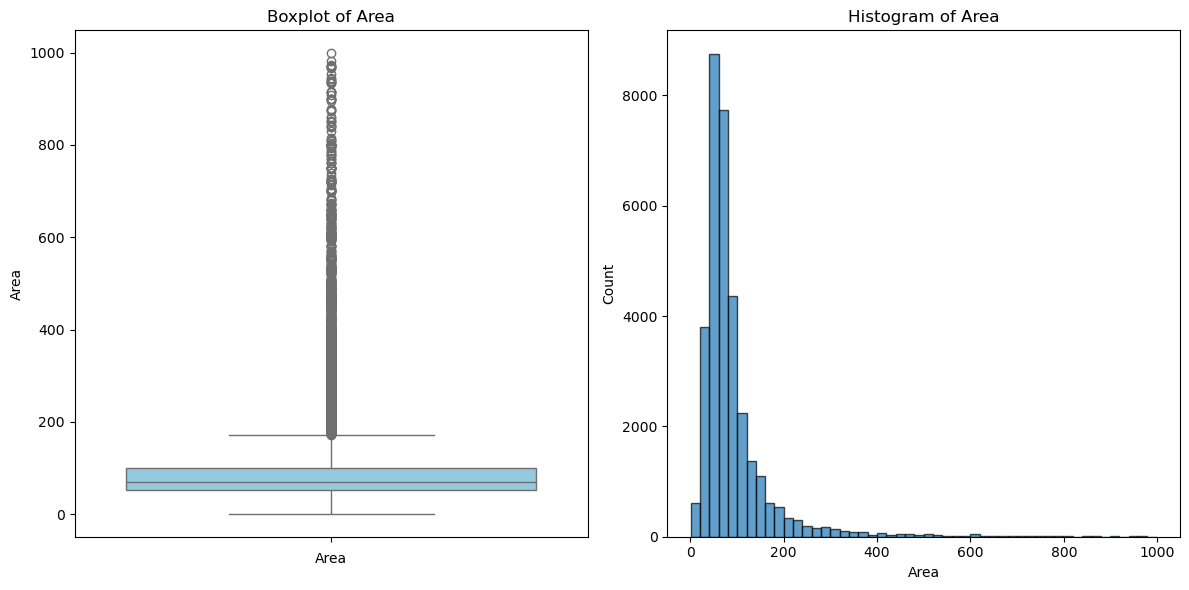

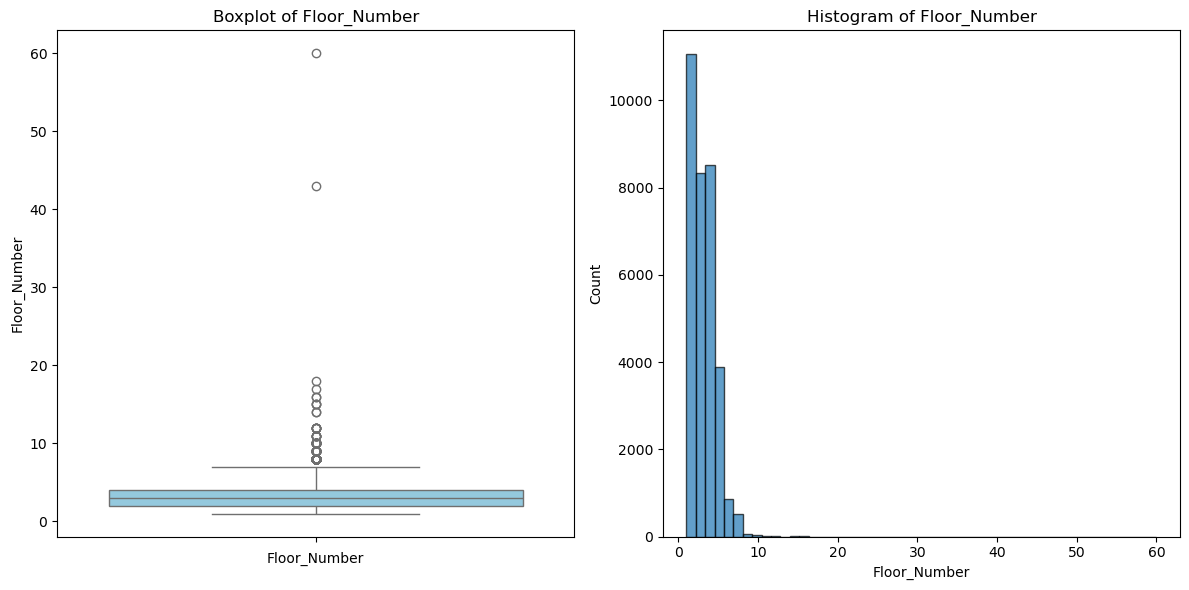

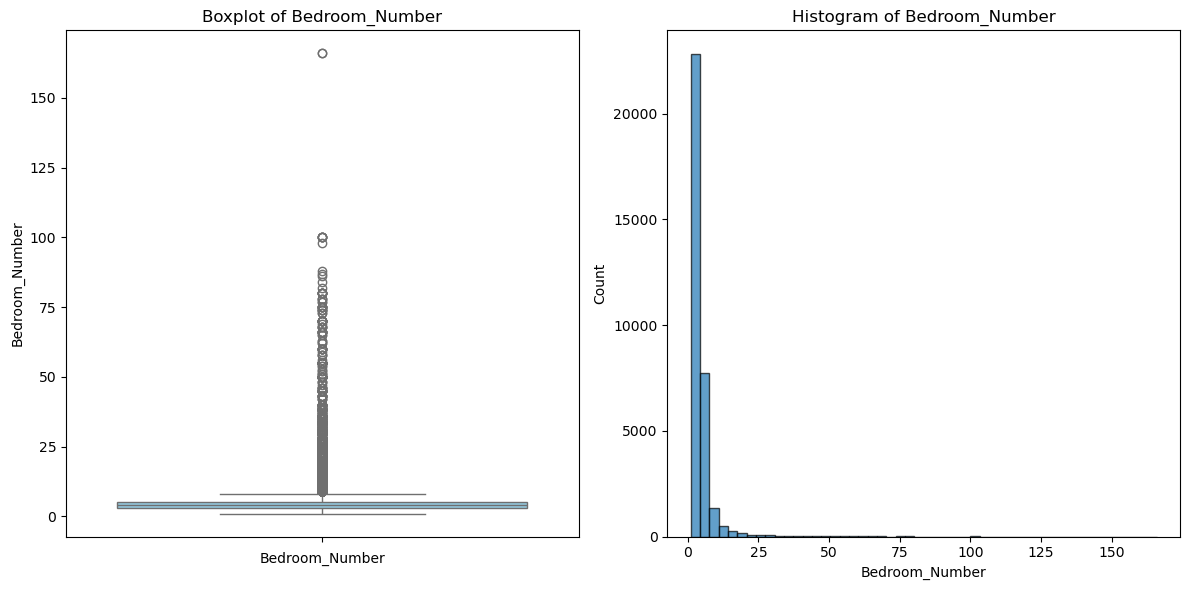

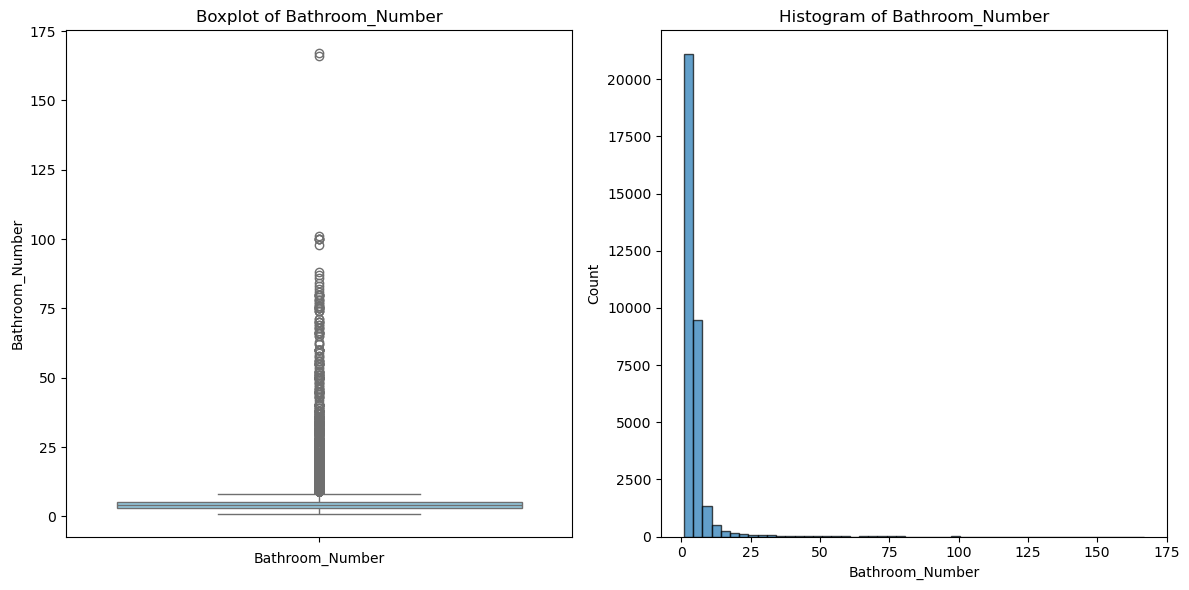

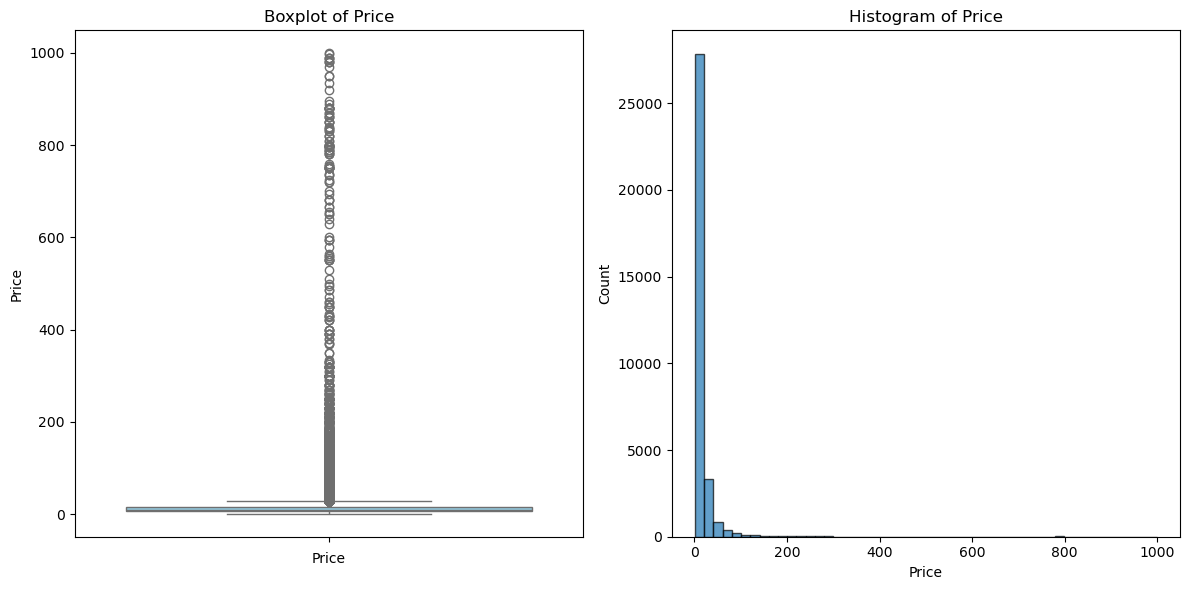

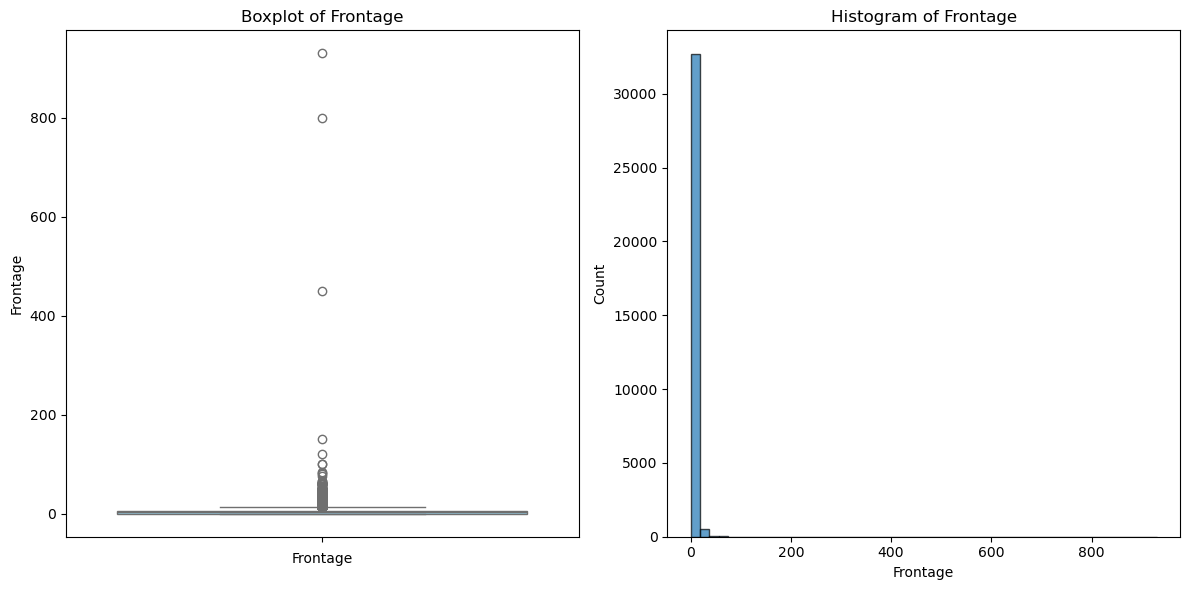

In [28]:
for col in numerical_cols:
    plt.figure(figsize=(12, 6))

    # ====== Subplot 1: Boxplot ======
    plt.subplot(1, 2, 1)
    sns.boxplot(y=df_filtered[col], color='skyblue')
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    # ====== Subplot 2: Histogram ======
    plt.subplot(1, 2, 2)
    plt.hist(df_filtered[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()


In [29]:
# Xử lý outlier dựa trên diện tích trung bình mỗi phòng ngủ
df_clean = prep.clean_outliers_real_estate(col_area="Area", col_price="Price", col_bedroom="Bedroom_Number")
df_clean.describe()

,Area,Floor_Number,Bedroom_Number,Bathroom_Number,Price,Frontage
count,29623.000000,29623.000000,29623.000000,29623.000000,29623.000000,29623.000000
mean,84.135341,3.196300,4.148331,4.091753,12.554620,4.207510
std,54.161924,1.260236,2.480103,2.583731,12.842863,8.515615
min,16.300000,1.000000,1.000000,1.000000,2.100000,0.000000
25%,53.000000,2.000000,3.000000,3.000000,6.200000,0.000000
50%,69.000000,3.000000,4.000000,4.000000,8.400000,4.000000
75%,98.300000,4.000000,5.000000,5.000000,13.500000,5.000000
max,480.000000,15.000000,55.000000,56.000000,120.000000,930.000000


In [30]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29623 entries, 0 to 29622
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   District         29623 non-null  object 
 1   Area             29623 non-null  float64
 2   Floor_Number     29623 non-null  float64
 3   Bedroom_Number   29623 non-null  float64
 4   Bathroom_Number  29623 non-null  float64
 5   Price            29623 non-null  float64
 6   Frontage         29623 non-null  float64
 7   Furniture        29623 non-null  object 
 8   Legal_Status     29623 non-null  object 
dtypes: float64(6), object(3)
memory usage: 2.0+ MB


# 3. MÔ HÌNH HỌC MÁY VÀ ĐÁNH GIÁ:

# 3.1. Load model config

In [31]:
# Đọc config cho model
parser = argparse.ArgumentParser()
parser.add_argument("--config", type=str, default=r"C:\Users\Dinh Binh An\OneDrive\Dai_hoc\nhap_mon_python\final_project\project_root\source_code\model\config.ini")
args, unknown = parser.parse_known_args()

In [32]:
# Load config
config = configparser.ConfigParser()
config.read(args.config)



['C:\\Users\\Dinh Binh An\\OneDrive\\Dai_hoc\\nhap_mon_python\\final_project\\project_root\\source_code\\model\\config.ini']

In [33]:
def parse_param_grid(section):
    """
    Chuyển param_grid từ config.ini sang dict chuẩn để đưa vào GridSearchCV.
    Ví dụ:
        n_estimators = 100, 200
    → { "n_estimators": [100, 200] }
    """
    param_grid = {}

    for key, value in section.items():
        value = value.strip()

        # Nếu rỗng thì bỏ qua
        if value == "":
            continue

        # Nếu có dấu phẩy → list
        if "," in value:
            items = [v.strip() for v in value.split(",")]
        else:
            items = [value]

        # Chuyển kiểu dữ liệu
        parsed_items = []
        for item in items:
            if item.lower() == "true":
                parsed_items.append(True)
            elif item.lower() == "false":
                parsed_items.append(False)
            else:
                try:
                    parsed_items.append(int(item))
                except ValueError:
                    try:
                        parsed_items.append(float(item))
                    except ValueError:
                        parsed_items.append(item)

        param_grid[key] = parsed_items

    return param_grid


In [34]:
# Parse hyperparameter cho từng model từ config.ini

# Linear Regression
param_lr = parse_param_grid(config["LINEAR_REGRESSION_PARAMS"])

# Random Forest
param_rf = parse_param_grid(config["RANDOM_FOREST_PARAMS"])

# Gradient Boosting
param_gb = parse_param_grid(config["GRADIENT_BOOSTING_PARAMS"])

## 3.2. Xử lý dữ liệu cho huấn luyện mô hình 


In [35]:
# Dữ liệu cho train mô hình 
df_md = df_clean.copy()

# Áp dụng phương pháp Ordinal Encoding

df_md = prep.encode_ordinal(
    col="Furniture",
    categories_order=["Không có", "Cơ bản", "Đầy đủ"]
)
# Áp dụng phương pháp Onehot Encoding
df_md = prep.encode_onehot(
    cols = ["Legal_Status"]
)

df_md.head()

,District,Area,Floor_Number,Bedroom_Number,Bathroom_Number,Price,Frontage,Furniture,Legal_Status_Có,Legal_Status_Không
0,Quận 9,80.0,3.0,4.0,4.0,7.90,0.0,0.0,True,False
1,Bình Tân,143.0,1.0,1.0,1.0,9.99,4.2,1.0,True,False
2,Nhà Bè,140.0,3.0,4.0,5.0,16.50,0.0,0.0,True,False
3,Tân Phú,52.0,3.0,4.0,4.0,9.90,4.3,0.0,True,False
4,Quận 12,85.0,2.0,3.0,3.0,6.30,7.0,1.0,True,False


## 3.3. Tạo đối tượng trainer

In [36]:
sys.path.append(r"C:\Users\Dinh Binh An\OneDrive\Dai_hoc\nhap_mon_python\final_project\project_root\source_code\model")

# Import module
from model_trainer import (
    ModelTrainer,
    LinearRegressionModel,
    RandomForestModel,
    GradientBoostingModel
)

# Tạo danh sách model cho bài toán
models = [
    LinearRegressionModel(param_grid=param_lr),
    RandomForestModel(param_grid=param_rf),
    GradientBoostingModel(param_grid=param_gb)
]

In [37]:
# Khởi tạo trainer
trainer = ModelTrainer(args.config, model_objects=models)

In [38]:
# Load data vào model
trainer.load_data(df_md)

(       District   Area  Floor_Number  Bedroom_Number  Bathroom_Number  \
 0        Quận 9   80.0           3.0             4.0              4.0   
 1      Bình Tân  143.0           1.0             1.0              1.0   
 2        Nhà Bè  140.0           3.0             4.0              5.0   
 3       Tân Phú   52.0           3.0             4.0              4.0   
 4       Quận 12   85.0           2.0             3.0              3.0   
 ...         ...    ...           ...             ...              ...   
 33263  Tân Bình   54.0           3.0             3.0              3.0   
 33264   Quận 12   20.0           2.0             2.0              1.0   
 33265   Thủ Đức   62.0           1.0             1.0              1.0   
 33266    Nhà Bè   78.0           1.0             3.0              2.0   
 33267  Bình Tân   56.0           2.0             2.0              2.0   
 
        Frontage  Furniture  Legal_Status_Có  Legal_Status_Không  
 0           0.0        0.0             Tru

## 3.4. Chia tập train/ test data

In [39]:
# Chia tập train/ test theo test_size trong config
X_train, X_test, y_train, y_test = trainer.split_data(trainer.X, trainer.y)

print(X_train.head())
print(X_test.head())
print(y_train.head())
print(y_test.head())


         District   Area  Floor_Number  Bedroom_Number  Bathroom_Number  \
1175    Phú Nhuận   67.0           3.0             4.0              3.0   
28786     Thủ Đức  123.0           1.0             3.0              2.0   
22496  Bình Thạnh   10.0           1.0             2.0              1.0   
31451     Tân Phú   48.0           2.0             2.0              3.0   
14555     Quận 12  144.0           5.0            20.0             20.0   

       Frontage  Furniture  Legal_Status_Có  Legal_Status_Không  
1175        4.1        1.0             True               False  
28786       0.0        2.0             True               False  
22496       0.0        1.0             True               False  
31451       4.0        2.0             True               False  
14555       0.0        0.0             True               False  
       District    Area  Floor_Number  Bedroom_Number  Bathroom_Number  \
28733    Quận 1   48.00           2.0             2.0              2.0   
14144

## 3.5. Tạo thuộc tính mới cho mapping District 

Ghi chú: xử lí sau khi tách train/ test để tránh data leak

In [40]:
# Tạo một feature mới Price_per_area nhằm mục đích mapping district
df_train = X_train.copy()
df_train["Price"] = y_train
df_train = DataPreprocessor.add_price_per_area(
    df_train,
    price_col="Price",
    area_col="Area",
    new_col="Price_per_area",
    scale_price=1000
)
X_train = df_train.drop(columns=["Price"])
y_train = df_train["Price"]

In [41]:
X_train.groupby("District")['Price_per_area'].mean()

District
Bình Chánh     990.588477
Bình Thạnh     674.577806
Bình Tân       171.381566
Cần Giờ        193.678460
Củ Chi         677.523465
Gò Vấp         287.610739
Hóc Môn       4242.515709
Nhà Bè         213.708776
Phú Nhuận      214.917507
Quận 1         813.092824
Quận 10        610.921770
Quận 11        193.292870
Quận 12       1130.071810
Quận 2        3051.625642
Quận 3        1697.376103
Quận 4         164.554720
Quận 5         302.227867
Quận 6        3200.116663
Quận 7         373.252285
Quận 8         407.439429
Quận 9         489.393545
Thủ Đức        538.769444
Tân Bình       171.133170
Tân Phú        395.759651
Name: Price_per_area, dtype: float64

In [42]:
# Tính trung bình price_per_area theo District
df_group = X_train.groupby("District")['Price_per_area'].mean().reset_index()

df_group = df_group.sort_values("Price_per_area")

# Chia thành 3 nhóm theo phân vị
df_group["Group"] = pd.qcut(
    df_group["Price_per_area"],
    q=3,
    labels=[1, 2, 3]
)

# Tạo dictionary mapping District → Group
district_group_map = dict(zip(df_group["District"], df_group["Group"]))
print(district_group_map)




{'Quận 4': 1, 'Tân Bình': 1, 'Bình Tân': 1, 'Quận 11': 1, 'Cần Giờ': 1, 'Nhà Bè': 1, 'Phú Nhuận': 1, 'Gò Vấp': 1, 'Quận 5': 2, 'Quận 7': 2, 'Tân Phú': 2, 'Quận 8': 2, 'Quận 9': 2, 'Thủ Đức': 2, 'Quận 10': 2, 'Bình Thạnh': 2, 'Củ Chi': 3, 'Quận 1': 3, 'Bình Chánh': 3, 'Quận 12': 3, 'Quận 3': 3, 'Quận 2': 3, 'Quận 6': 3, 'Hóc Môn': 3}


In [43]:
# Mapping theo district_group_map
X_train['District'] = X_train['District'].map(district_group_map)
X_test['District'] = X_test['District'].map(district_group_map)

X_train = X_train.drop(columns=["Price_per_area"])

#lưu lại dataframe vào trainer
trainer.X_train = X_train
trainer.X_test = X_test

In [44]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26614 entries, 1175 to 15795
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   District            26614 non-null  int64  
 1   Area                26614 non-null  float64
 2   Floor_Number        26614 non-null  float64
 3   Bedroom_Number      26614 non-null  float64
 4   Bathroom_Number     26614 non-null  float64
 5   Frontage            26614 non-null  float64
 6   Furniture           26614 non-null  float64
 7   Legal_Status_Có     26614 non-null  bool   
 8   Legal_Status_Không  26614 non-null  bool   
dtypes: bool(2), float64(6), int64(1)
memory usage: 1.7 MB


In [45]:
X_train.head()

,District,Area,Floor_Number,Bedroom_Number,Bathroom_Number,Frontage,Furniture,Legal_Status_Có,Legal_Status_Không
1175,1,67.0,3.0,4.0,3.0,4.1,1.0,True,False
28786,2,123.0,1.0,3.0,2.0,0.0,2.0,True,False
22496,2,10.0,1.0,2.0,1.0,0.0,1.0,True,False
31451,2,48.0,2.0,2.0,3.0,4.0,2.0,True,False
14555,3,144.0,5.0,20.0,20.0,0.0,0.0,True,False


## 3.6. Vẽ Heat map 

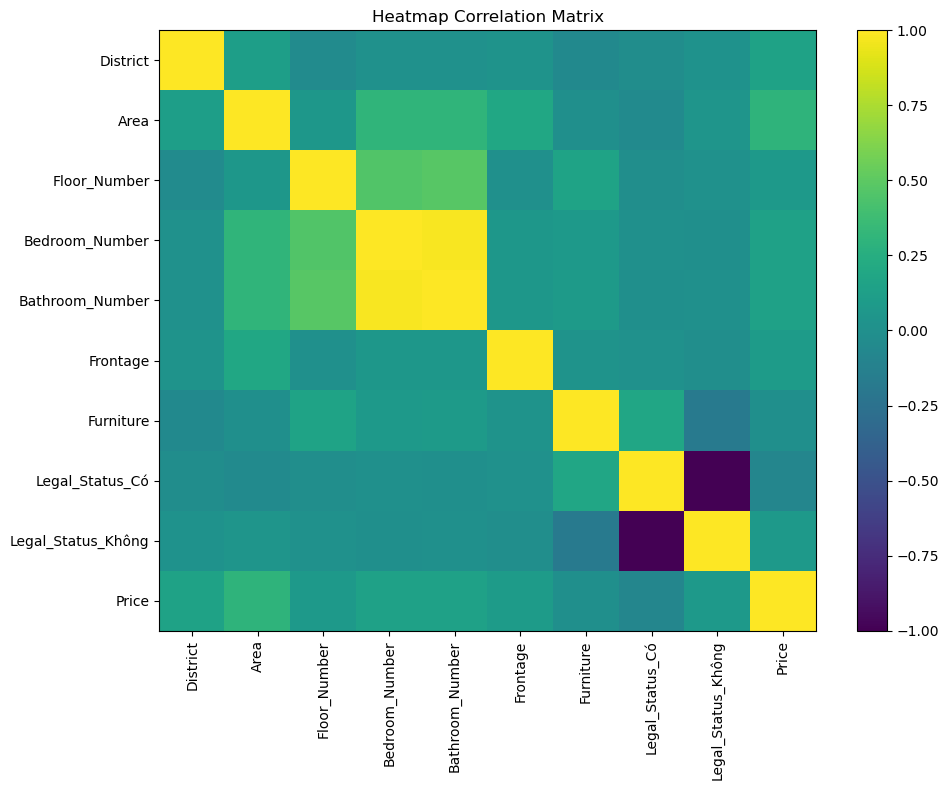

In [46]:
# Vẽ biểu đồ heatmap để thấy được độ tương quan của các features:
df_train = X_train.copy()
df_train["Price"] = y_train.values
corr = df_train.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Heatmap Correlation Matrix")
plt.tight_layout()
plt.show()

## 3.7. Chạy huấn luyện

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits


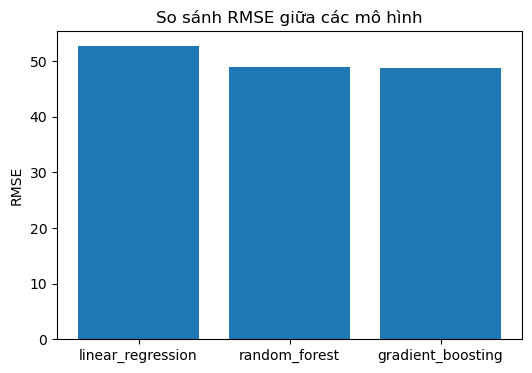

Best model: gradient_boosting đã được lưu vào best_model.pkl

----- KẾT QUẢ TRAINING -----
            model      RMSE       MAE       R2
linear_regression 52.743068 13.051636 0.093615
    random_forest 48.870770 10.437570 0.221819
gradient_boosting 48.840696 10.583181 0.222777


In [47]:
# Chạy thử nghiệm để tối ưu tham số và chọn mô hình tốt nhất:

# Chạy thử nghiệm
trainer.experiment()

# Lưu mô hình tốt nhất
trainer.save_model("best_model.pkl")
print(f"Best model: {trainer.best_model_name} đã được lưu vào best_model.pkl")

# Hiển thị toàn bộ kết quả
print("\n----- KẾT QUẢ TRAINING -----")
df = pd.DataFrame(trainer.results)
print(df.to_string(index=False))

## 3.8. Trực quan hóa khả năng của best model

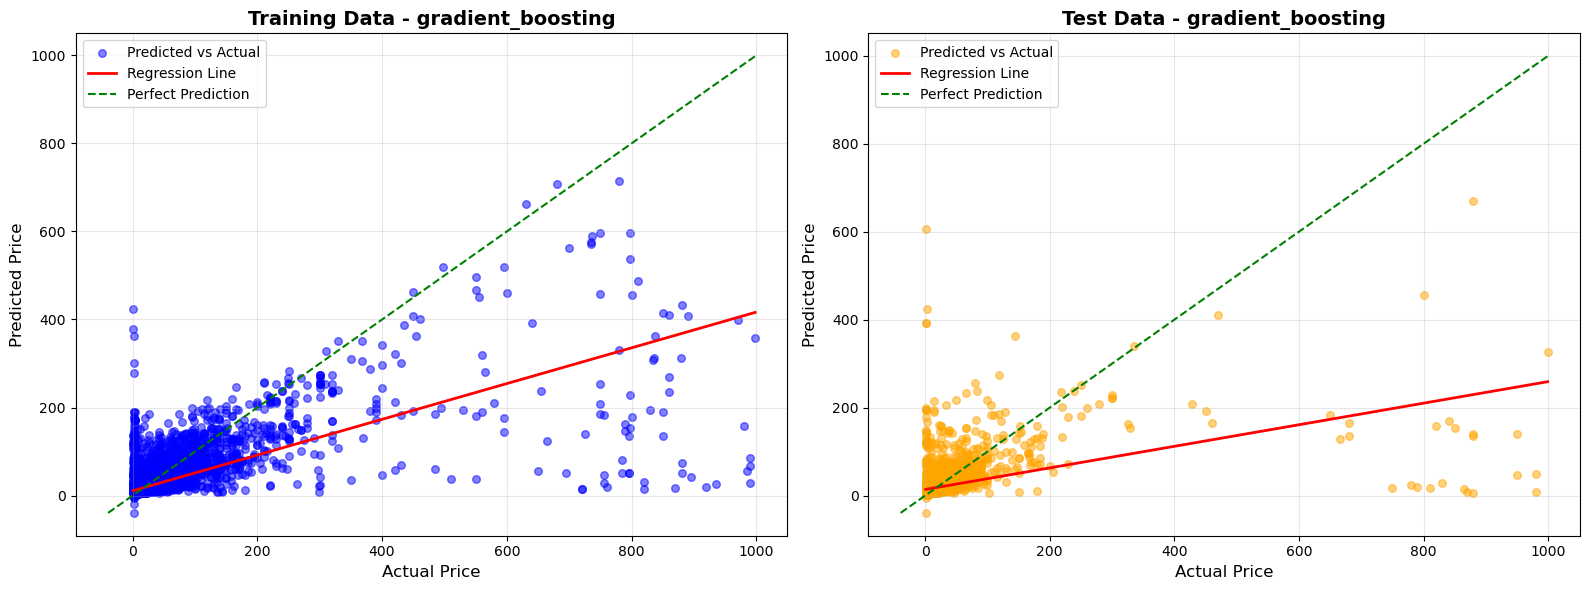


=== THÔNG TIN ĐƯỜNG HỒI QUY ===
Training - Hệ số góc (slope): 0.4059
Training - Hệ số tự do (intercept): 10.9032

Test - Hệ số góc (slope): 0.2452
Test - Hệ số tự do (intercept): 13.9760


In [48]:
# Lấy predictions từ best model
y_pred_train = trainer.best_model.predict(X_train)
y_pred_test = trainer.best_model.predict(X_test)

# Tạo figure với 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SUBPLOT 1: TRAINING DATA 
ax1 = axes[0]
ax1.scatter(y_train, y_pred_train, alpha=0.5, s=30, color='blue', label='Predicted vs Actual')

# Vẽ đường hồi quy cho training data
z_train = np.polyfit(y_train, y_pred_train, 1)
p_train = np.poly1d(z_train)
y_train_line = np.linspace(y_train.min(), y_train.max(), 100)
ax1.plot(y_train_line, p_train(y_train_line), "r-", linewidth=2, label='Regression Line')

# Đường perfect prediction (y = x)
min_val = min(y_train.min(), y_pred_train.min())
max_val = max(y_train.max(), y_pred_train.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'g--', linewidth=1.5, label='Perfect Prediction')

ax1.set_xlabel('Actual Price', fontsize=12)
ax1.set_ylabel('Predicted Price', fontsize=12)
ax1.set_title(f'Training Data - {trainer.best_model_name}', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# SUBPLOT 2: TEST DATA 
ax2 = axes[1]
ax2.scatter(y_test, y_pred_test, alpha=0.5, s=30, color='orange', label='Predicted vs Actual')

# Vẽ đường hồi quy cho test data
z_test = np.polyfit(y_test, y_pred_test, 1)
p_test = np.poly1d(z_test)
y_test_line = np.linspace(y_test.min(), y_test.max(), 100)
ax2.plot(y_test_line, p_test(y_test_line), "r-", linewidth=2, label='Regression Line')

# Đường perfect prediction (y = x)
min_val_test = min(y_test.min(), y_pred_test.min())
max_val_test = max(y_test.max(), y_pred_test.max())
ax2.plot([min_val_test, max_val_test], [min_val_test, max_val_test], 'g--', linewidth=1.5, label='Perfect Prediction')

ax2.set_xlabel('Actual Price', fontsize=12)
ax2.set_ylabel('Predicted Price', fontsize=12)
ax2.set_title(f'Test Data - {trainer.best_model_name}', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# In ra thông tin về đường hồi quy
print("\n=== THÔNG TIN ĐƯỜNG HỒI QUY ===")
print(f"Training - Hệ số góc (slope): {z_train[0]:.4f}")
print(f"Training - Hệ số tự do (intercept): {z_train[1]:.4f}")
print(f"\nTest - Hệ số góc (slope): {z_test[0]:.4f}")
print(f"Test - Hệ số tự do (intercept): {z_test[1]:.4f}")


**Nhận xét**:
- Mô hình Gradient Boosting học được xu hướng chung giữa giá thực và giá dự đoán.

- Dự đoán khá tốt với nhà giá thấp – trung bình, nơi dữ liệu tập trung nhiều.

- Underestimate nghiêm trọng nhà giá cao: khi giá thực tăng lớn, giá dự đoán không theo kịp.

- Kết quả trên train và test tương tự nhau → không overfitting, nhưng tồn tại bias hệ thống.

- Mô hình chưa phù hợp cho phân khúc nhà cao cấp, cần cải thiện (ví dụ: log-transform giá, chia phân khúc, hoặc tuning mô hình).